# Importations

In [ ]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local imports
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map, compute_bloch_norms_from_dm
from moments.initialization import (compute_param_from_X, compute_X_from_param, compute_dm_from_X, optmize_initial_param)

# Parametrization of the density matrix

## Non-Cholesky case

In [2]:
d = 2

X = np.random.randn(d, d) + 1j * np.random.randn(d, d)
x = compute_param_from_X(X)
X_rec = compute_X_from_param(x)

print("Parameter vector is real:", np.isreal(x).all())
print("Parameter vector has appropriate dimension:", x.shape[0] == 2 * d**2)


print("\nParameter matrix is complex:", np.iscomplex(X).all())
print("Reconstructec parameter matrix is complex:", np.iscomplex(X_rec).all())
print("Reconstructec parameter matrix has appropriate dimension:", X_rec.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(X, X_rec).all())

Parameter vector is real: True
Parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Reconstructec parameter matrix is complex: True
Reconstructec parameter matrix has appropriate dimension: True

One way reconstruction works: True


In [3]:
x = np.random.randn(2 * d**2)
X = compute_X_from_param(x)
x_rec = compute_param_from_X(X)

print("Parameter vector is real:", np.isreal(x).all())
print("Reconstructed parameter vector is real:", np.isreal(x_rec).all())
print("Reconstructed parameter vector has appropriate dimension:", x_rec.shape[0] == 2 * d**2)

print("\nParameter matrix is complex:", np.iscomplex(X).all())
print("Parameter matrix has appropriate dimension:", X.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(x, x_rec).all())

Parameter vector is real: True
Reconstructed parameter vector is real: True
Reconstructed parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Parameter matrix has appropriate dimension: True

One way reconstruction works: True


## Cholesky case

In [4]:
d = 4

X = np.random.randn(d, d) + 1j * np.random.randn(d, d)
X = np.tril(X)
x = compute_param_from_X(X, cholesky=True)
X_rec = compute_X_from_param(x, cholesky=True)

print("Parameter vector is real:", np.isreal(x).all())
print("Parameter vector has appropriate dimension:", x.shape[0] == d * (d + 1))

print("\nParameter matrix is lower triangular:", np.allclose(X, np.tril(X)))
print("Reconstructed parameter matrix is lower triangular:", np.allclose(X_rec, np.tril(X_rec)))

print("\nParameter matrix is complex:", np.logical_or(np.iscomplex(X), np.isclose(X, np.zeros_like(X))).all())
print("Reconstructed parameter matrix is complex:", np.logical_or(np.iscomplex(X_rec), np.isclose(X_rec, np.zeros_like(X_rec))).all())
print("Reconstructed parameter matrix has appropriate dimension:", X_rec.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(X, X_rec).all())

Parameter vector is real: True
Parameter vector has appropriate dimension: True

Parameter matrix is lower triangular: True
Reconstructed parameter matrix is lower triangular: True

Parameter matrix is complex: True
Reconstructed parameter matrix is complex: True
Reconstructed parameter matrix has appropriate dimension: True

One way reconstruction works: True


In [5]:
x = np.random.randn(d * (d + 1))
X = compute_X_from_param(x, cholesky=True)
x_rec = compute_param_from_X(X, cholesky=True)

print("Parameter vector is real:", np.isreal(x).all())
print("Reconstructed parameter vector is real:", np.isreal(x_rec).all())
print("Reconstructed parameter vector has appropriate dimension:", x_rec.shape[0] == d * (d + 1))

print("\nParameter matrix is complex:", np.logical_or(np.iscomplex(X), np.isclose(X, np.zeros_like(X))).all())
print("Parameter matrix has appropriate dimension:", X.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(x, x_rec).all())

Parameter vector is real: True
Reconstructed parameter vector is real: True
Reconstructed parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Parameter matrix has appropriate dimension: True

One way reconstruction works: True


# Optimization functions

## Space definition and discretization

In [6]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [7]:
D = 20
Dx, Dy, Dz = D + 1, D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
y = np.linspace(0, 1, Dy)
z = np.linspace(0, np.sqrt(3), Dz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

mask1 = Z >= X + Y - 1
mask2 = Z**2 <= 3 + X**2 + Y**2 - 4*X*Y - 4*np.abs(X - Y)
mask = mask1 & mask2

points = np.column_stack((X[mask], Y[mask], Z[mask]))
print(f"Number of points: {points.shape[0]}")

Number of points: 7910


## Optimization non-Cholesky

In [ ]:
times, solutions, R_list = [], [], []

for i, (x_val, y_val, z_val) in enumerate(points, 1):
    t0 = time.time()
    
    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}
    
    x = optmize_initial_param(d, tensor_basis, subset_index_map, Rt)
    
    tf = time.time()
    times.append(tf - t0)
    solutions.append(x)
    R_list.append(Rt)

    if i % 200 == 0:
        print(f'Progress: {i*100/points.shape[0]:.2f}%')

Progress: 2.53%
Progress: 5.06%
Progress: 7.59%
Progress: 10.11%
Progress: 12.64%
Progress: 15.17%
Progress: 17.70%
Progress: 20.23%
Progress: 22.76%
Progress: 25.28%
Progress: 27.81%
Progress: 30.34%
Progress: 32.87%
Progress: 35.40%
Progress: 37.93%
Progress: 40.46%
Progress: 42.98%
Progress: 45.51%
Progress: 48.04%
Progress: 50.57%
Progress: 53.10%
Progress: 55.63%
Progress: 58.15%
Progress: 60.68%
Progress: 63.21%
Progress: 65.74%
Progress: 68.27%
Progress: 70.80%
Progress: 73.32%
Progress: 75.85%
Progress: 78.38%
Progress: 80.91%
Progress: 83.44%
Progress: 85.97%
Progress: 88.50%
Progress: 91.02%
Progress: 93.55%
Progress: 96.08%
Progress: 98.61%


In [9]:
errors, R_app = [], []
times = np.array(times)
solutions = np.array(solutions)
R_list = np.array(R_list)

for xdx, x in enumerate(solutions):
    X = compute_X_from_param(x)
    rho = compute_dm_from_X(X)
    R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)
    R_app.append(R)
    e = 0
    for subset in R.keys():
        e += np.abs(R[subset] - R_list[xdx][subset])
    errors.append(e)

errors = np.array(errors)
R_app = np.array(R_app)

print(f'Total time: {np.sum(times)/60:0.2f} min.\n')
print(f'Average error: {np.mean(errors)}.\n')

print(f'Max error:{errors[np.argmax(errors)]}.')
print(f'R_target = {R_list[np.argmax(errors)]}.')
print(f'R_app = {R_app[np.argmax(errors)]}.\n')

print(f'Min error:{errors[np.argmin(errors)]}.')
print(f'R_target = {R_list[np.argmin(errors)]}.')
print(f'R_app = {R_app[np.argmin(errors)]}.')

Total time: 0.51 min.

Average error: 5.987187951381103e-06.

Max error:0.0002748210313909816.
R_target = {(1,): 0.5, (2,): 0.5, (1, 2): 1.5792227951363291}.
R_app = {(1,): np.float64(0.5000296051001747), (2,): np.float64(0.4999028129510865), (1, 2): np.float64(1.5790747662540263)}.

Min error:5.39278804945198e-09.
R_target = {(1,): 0.45, (2,): 0.25, (1, 2): 0.9679107454061372}.
R_app = {(1,): np.float64(0.4499999968009158), (2,): np.float64(0.25000000055948673), (1, 2): np.float64(0.9679107437719201)}.


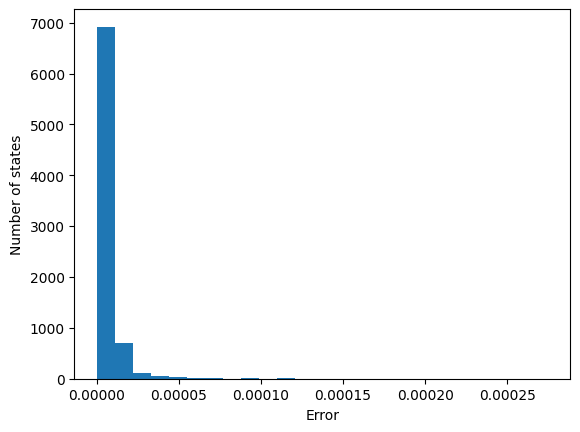

In [10]:
plt.hist(errors, bins=25)
plt.xlabel('Error')
plt.ylabel('Number of states')
plt.show()

## Optimization Cholesky

In [ ]:
times, solutions, R_list = [], [], []

for i, (x_val, y_val, z_val) in enumerate(points, 1):
    t0 = time.time()
    
    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}
    
    x = optmize_initial_param(d, tensor_basis, subset_index_map, Rt, cholesky=True)
    
    tf = time.time()
    times.append(tf - t0)
    solutions.append(x)
    R_list.append(Rt)

    if i % 200 == 0:
        print(f'Progress: {i*100/points.shape[0]:.2f}%')

Progress: 2.53%
Progress: 5.06%
Progress: 7.59%
Progress: 10.11%
Progress: 12.64%
Progress: 15.17%
Progress: 17.70%
Progress: 20.23%
Progress: 22.76%
Progress: 25.28%
Progress: 27.81%
Progress: 30.34%
Progress: 32.87%
Progress: 35.40%
Progress: 37.93%
Progress: 40.46%
Progress: 42.98%
Progress: 45.51%
Progress: 48.04%
Progress: 50.57%
Progress: 53.10%
Progress: 55.63%
Progress: 58.15%
Progress: 60.68%
Progress: 63.21%
Progress: 65.74%
Progress: 68.27%
Progress: 70.80%
Progress: 73.32%
Progress: 75.85%
Progress: 78.38%
Progress: 80.91%
Progress: 83.44%
Progress: 85.97%
Progress: 88.50%
Progress: 91.02%
Progress: 93.55%
Progress: 96.08%
Progress: 98.61%


In [12]:
errors, R_app = [], []
times = np.array(times)
solutions = np.array(solutions)
R_list = np.array(R_list)

for xdx, x in enumerate(solutions):
    X = compute_X_from_param(x, cholesky=True)
    rho = compute_dm_from_X(X)
    R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)
    R_app.append(R)
    e = 0
    for subset in R.keys():
        e += np.abs(R[subset] - R_list[xdx][subset])
    errors.append(e)

errors = np.array(errors)
R_app = np.array(R_app)

print(f'Total time: {np.sum(times)/60:0.2f} min.\n')
print(f'Average error: {np.mean(errors)}.\n')

print(f'Max error:{errors[np.argmax(errors)]}.')
print(f'R_target = {R_list[np.argmax(errors)]}.')
print(f'R_app = {R_app[np.argmax(errors)]}.\n')

print(f'Min error:{errors[np.argmin(errors)]}.')
print(f'R_target = {R_list[np.argmin(errors)]}.')
print(f'R_app = {R_app[np.argmin(errors)]}.')

Total time: 0.96 min.

Average error: 3.793822146392189e-05.

Max error:0.15000000087640933.
R_target = {(1,): 0.05, (2,): 0.8, (1, 2): 0.0}.
R_app = {(1,): np.float64(0.10000009809987291), (2,): np.float64(0.8499996497136493), (1, 2): np.float64(0.0500002530628872)}.

Min error:5.756480014884602e-09.
R_target = {(1,): 0.30000000000000004, (2,): 0.45, (1, 2): 0.8660254037844386}.
R_app = {(1,): np.float64(0.2999999979536156), (2,): np.float64(0.4499999985993625), (1, 2): np.float64(0.8660254014749805)}.


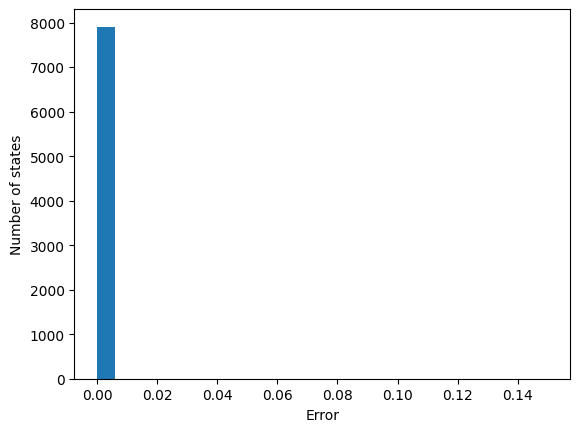

In [13]:
plt.hist(errors, bins=25)
plt.xlabel('Error')
plt.ylabel('Number of states')
plt.show()